## Setups & Imports

In [114]:
from pathlib import Path
import sys
from importlib import reload

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from cycler import cycler
from matplotlib.ticker import ScalarFormatter

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "app").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import app.core.config as config

reload(config)
settings = config.settings

PLOT_PRIMARY_COLOR = "#5F9EA0"
PLOT_SECONDARY_COLOR = "#457B9D"
PLOT_ACCENT_COLOR = "#E74C3C"
PLOT_EDGE_COLOR = "white"
PLOT_ALPHA = 0.9
PLOT_LINE_WIDTH = 2
PLOT_HIST_LINEWIDTH = 0.8
PLOT_STYLE = {
    "figure.figsize": (10, 6),
    "figure.dpi": 110,
    "axes.facecolor": "white",
    "figure.facecolor": "white",
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.alpha": 0.35,
    "grid.color": "black",
    "grid.linestyle": "--",
    "grid.linewidth": 0.8,
    "axes.edgecolor": "#C7CCD1",
    "axes.linewidth": 1.0,
    "axes.prop_cycle": cycler(
        color=[
            PLOT_PRIMARY_COLOR,
            PLOT_SECONDARY_COLOR,
            PLOT_ACCENT_COLOR,
            "#2A9D8F",
            "#E9C46A",
            "#F4A261",
        ]
    ),
    "lines.linewidth": PLOT_LINE_WIDTH,
    "patch.edgecolor": PLOT_EDGE_COLOR,
    "patch.linewidth": PLOT_HIST_LINEWIDTH,
}

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(PLOT_STYLE)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

---

## Loading the Data

In [115]:
data = settings.load_data("raw")
data.head(5)

,id,title,make,model,year,mileage_km,transmission,fuel,price_egp,location,scraped_at
0,1,Deepal S 07 2025,Deepal,S 07,2025.0,5000.0,Automatic,hybrid,1650000,"Sheikh Zayed, Giza•",2026-02-20 04:45:52
1,2,Chery Tiggo 2026,Chery,Tiggo,2026.0,NaN,Manual,petrol,915000,NaN,2026-02-20 04:50:40
2,3,Byd F3 2024,BYD,F3,2024.0,4410.0,Manual,petrol,630000,"Ramses + Ramses Extension, Cairo•",2026-02-20 04:41:57
3,4,Byd F3 2025,BYD,F3,2025.0,33033.0,Manual,petrol,610000,"Nasr City, Cairo•",2026-02-20 04:54:05
4,5,Subaru Impreza 2009,Subaru,Impreza,2009.0,98000.0,Manual,petrol,410000,"Maadi, Cairo•",2026-02-20 04:41:57


In [116]:
data.shape

(26656, 11)

---

## Data Exploration 

In [117]:
data.describe()

,id,year,mileage_km,price_egp
count,26656.000000,26454.000000,2.660600e+04,2.665600e+04
mean,13481.963198,2014.172337,1.789412e+05,4.171486e+09
std,7764.640531,9.879104,6.217396e+06,6.805500e+11
min,1.000000,1950.000000,0.000000e+00,0.000000e+00
25%,6762.750000,2008.000000,2.400000e+04,3.000000e+05
50%,13504.500000,2016.000000,1.100000e+05,6.100000e+05
75%,20202.250000,2022.000000,1.950000e+05,1.250000e+06
max,26895.000000,2027.000000,1.000000e+09,1.111111e+14


I need to validate the edge cases and outliers as the 1950 car and 2027 hah

mileage_km max: 1,000,000,000 km (1 billion km) That's physically impossible. Earth's circumference is 40K km hah

Price column seem have unlogical outlirs 

In [118]:
data.describe(include=['object', 'string'])

,title,make,model,transmission,fuel,location,scraped_at
count,26656,26656,26656,26625,26607,26198,26656
unique,5985,114,1035,4,5,1096,15846
top,Renault Logan 2016,Mercedes,Lanos,Automatic,petrol,"Tagamo3 - New Cairo, Cairo",2026-02-20 04:44:22
freq,87,2435,663,18986,23640,1882,189


In [119]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 26656 entries, 0 to 26655
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            26656 non-null  int64  
 1   title         26656 non-null  str    
 2   make          26656 non-null  str    
 3   model         26656 non-null  str    
 4   year          26454 non-null  float64
 5   mileage_km    26606 non-null  float64
 6   transmission  26625 non-null  str    
 7   fuel          26607 non-null  str    
 8   price_egp     26656 non-null  int64  
 9   location      26198 non-null  str    
 10  scraped_at    26656 non-null  str    
dtypes: float64(2), int64(2), str(7)
memory usage: 4.4 MB


I don't need the id mostly I will delete it and maybe normalize the location to the government or delete it at all

---

---

## Checking duplicates

In [120]:
data.duplicated().sum()

np.int64(0)

In [121]:
data.drop(["id"], axis=1).duplicated().sum()

np.int64(32)

In [122]:
data.drop(["id", "location"], axis=1).duplicated().sum()

np.int64(67)

 67 rows minor I will drop them but I will take a look first


In [123]:
data[data.drop(["id", "location"], axis=1).duplicated(keep=False)].tail(20)

,id,title,make,model,year,mileage_km,transmission,fuel,price_egp,location,scraped_at
10351,10503,Fiat Shahin 2008,Fiat,Shahin,2008.0,137000.0,Manual,petrol,180000,•,2026-02-20 04:55:29.000000
10353,10505,Fiat Shahin 2008,Fiat,Shahin,2008.0,137000.0,Manual,petrol,180000,"Hadayek al-Ahram, Giza•",2026-02-20 04:55:29.000000
10410,10562,Suzuki Alto 2013,Suzuki,Alto,2013.0,77000.0,Manual,petrol,210000,"Cairo Alexandria Desert Road, 6th of October•",2026-02-20 04:55:44.000000
10411,10563,Suzuki Alto 2013,Suzuki,Alto,2013.0,77000.0,Manual,petrol,210000,•,2026-02-20 04:55:44.000000
10599,10755,Ford Bronco Raptor 1999,Ford,Bronco Raptor,1999.0,100000.0,Manual,petrol,155000,"6th of October, Giza•",2026-02-20 04:56:48.000000
10604,10760,Ford Bronco Raptor 1999,Ford,Bronco Raptor,1999.0,100000.0,Manual,petrol,155000,"Zayed Heights, Sheikh Zayed•",2026-02-20 04:56:48.000000
10624,10780,Daewoo Matiz 1999,Daewoo,Matiz,1999.0,1.0,Manual,petrol,150000,•,2026-02-20 04:56:48.000000
10626,10782,Daewoo Matiz 1999,Daewoo,Matiz,1999.0,1.0,Manual,petrol,150000,"Haram, Giza•",2026-02-20 04:56:48.000000
10628,10784,Fiat Shahin 1995,Fiat,Shahin,1995.0,120000.0,Manual,petrol,155000,"Helwan, Cairo•",2026-02-20 04:56:48.000000
10632,10788,Fiat Shahin 1995,Fiat,Shahin,1995.0,120000.0,Manual,petrol,155000,"Helwan, Cairo•",2026-02-20 04:56:48.000000


---

---

## Nulls detection

In [124]:
data.isna().sum()

id                0
title             0
make              0
model             0
year            202
mileage_km       50
transmission     31
fuel             49
price_egp         0
location        458
scraped_at        0
dtype: int64

---

### inspecting fuel 49 nulls

In [125]:
data.fuel.value_counts().to_frame()

,count
fuel,
petrol,23640
diesel,1515
cng,619
electric,532
hybrid,301


In [126]:
data[data['fuel'].isnull()].head()

,id,title,make,model,year,mileage_km,transmission,fuel,price_egp,location,scraped_at
11827,11993,Volkswagen Golf 6 2011,Volkswagen,Golf 6,2011.0,320000.0,Automatic,NaN,590000,"Kom Hamada, Beheira",2026-02-20 00:36:17.353071
12349,12518,Mitsubishi Lancer EX Shark 2016,Mitsubishi,Lancer EX Shark,2016.0,0.0,Manual,NaN,600,Cairo,2026-02-20 00:39:01.502827
12572,12742,Toyota Corolla 2013,Toyota,Corolla,2013.0,150000.0,Automatic,NaN,750000,El Mansoura,2026-02-20 00:40:16.184202
12759,12929,Mercedes GLC300 AMG 2022,Mercedes,GLC300,2022.0,7000.0,Automatic,NaN,4100000,Cairo,2026-02-20 00:41:12.294651
12901,13073,Deepal S 05 2026,Deepal,S 05,2026.0,0.0,Automatic,NaN,1490000,"Dokki, Giza",2026-02-20 00:41:57.417399


take a look if there are another cars of the same make and model and fuel is exist

In [127]:
data[(data['make'] == "Volkswagen") & (data['model'] == "Golf 6")].head()

,id,title,make,model,year,mileage_km,transmission,fuel,price_egp,location,scraped_at
11054,11215,Volkswagen Golf 6 2004,Volkswagen,Golf 6,2004.0,100000.0,Automatic,petrol,425000,El Mahalla El Kubra,2026-02-20 00:31:03.531793
11449,11613,Volkswagen Golf 6 2011,Volkswagen,Golf 6,2011.0,152000.0,Automatic,petrol,650000,"Tagamo3 - New Cairo, Cairo",2026-02-20 00:32:56.299680
11713,11878,Volkswagen Golf 6 2012,Volkswagen,Golf 6,2012.0,250000.0,Automatic,petrol,680000,"Tagamo3 - New Cairo, Cairo",2026-02-20 00:35:42.616085
11827,11993,Volkswagen Golf 6 2011,Volkswagen,Golf 6,2011.0,320000.0,Automatic,NaN,590000,"Kom Hamada, Beheira",2026-02-20 00:36:17.353071
13455,13633,Volkswagen Golf 6 2024,Volkswagen,Golf 6,2024.0,40000.0,Automatic,petrol,1385000,"Tagamo3 - New Cairo, Cairo",2026-02-20 00:45:24.228985


so I can create funciton that impute by the same fual as the make and model and year and if there is no exact same year so the same make and model only, but I need to verify other nulls

In [128]:
data[(data['make'] == "Mitsubishi") & (data['model'] == "Lancer EX Shark") & (data['year'] == 2016)].head()

,id,title,make,model,year,mileage_km,transmission,fuel,price_egp,location,scraped_at
7501,7612,Mitsubishi Lancer EX Shark 2016,Mitsubishi,Lancer EX Shark,2016.0,100000.0,Automatic,petrol,650000,"Heliopolis, Cairo•",2026-02-20 04:55:14
11249,11411,Mitsubishi Lancer EX Shark 2016,Mitsubishi,Lancer EX Shark,2016.0,313000.0,Automatic,diesel,475000,"Hadayek October, Giza",2026-02-20 00:32:02.377098
12130,12298,Mitsubishi Lancer EX Shark 2016,Mitsubishi,Lancer EX Shark,2016.0,147000.0,Automatic,petrol,540000,"6 October, Giza",2026-02-20 00:37:44.483750
12152,12320,Mitsubishi Lancer EX Shark 2016,Mitsubishi,Lancer EX Shark,2016.0,230000.0,Automatic,diesel,625000,"Hurghada, Red Sea",2026-02-20 00:37:55.195477
12349,12518,Mitsubishi Lancer EX Shark 2016,Mitsubishi,Lancer EX Shark,2016.0,0.0,Manual,NaN,600,Cairo,2026-02-20 00:39:01.502827


here it's not the same this car seems to be data entry error the price is 600 I can assume he means 600k but it's the only one manual 
after searching I found that Mitsubishi	Lancer EX Shark 2016 is only automatic it's a data entry error

In [129]:
def show_null_fuel_comparisons(df, n_compare=3):
    null_rows = df[df["fuel"].isna()].copy()
    if null_rows.empty:
        return null_rows

    comparisons = []

    for idx, row in null_rows.iterrows():
        null_sample = row.to_frame().T
        null_sample.insert(0, "row_type", "null_fuel_row")
        null_sample.insert(1, "source_null_row_index", idx)

        same_mm = df[
            (df["make"] == row["make"]) &
            (df["model"] == row["model"]) &
            (df["fuel"].notna())
        ].head(n_compare).copy()

        if same_mm.empty:
            comparisons.append(null_sample)
            continue

        same_mm.insert(0, "row_type", "same_make_model_non_null")
        same_mm.insert(1, "source_null_row_index", idx)

        comparisons.append(pd.concat([null_sample, same_mm], ignore_index=True))

    return pd.concat(comparisons, ignore_index=True)

fuel_null_comparison_df = show_null_fuel_comparisons(data, n_compare=3)
fuel_null_comparison_df[["make", "model", "year", "transmission", "fuel", "price_egp"]]


,make,model,year,transmission,fuel,price_egp
0,Volkswagen,Golf 6,2011.0,Automatic,NaN,590000
1,Volkswagen,Golf 6,2004.0,Automatic,petrol,425000
2,Volkswagen,Golf 6,2011.0,Automatic,petrol,650000
3,Volkswagen,Golf 6,2012.0,Automatic,petrol,680000
4,Mitsubishi,Lancer EX Shark,2016.0,Manual,NaN,600
5,Mitsubishi,Lancer EX Shark,2018.0,Automatic,petrol,900000
6,Mitsubishi,Lancer EX Shark,2002.0,Automatic,petrol,290000
7,Mitsubishi,Lancer EX Shark,2024.0,Automatic,petrol,1250000
8,Toyota,Corolla,2013.0,Automatic,NaN,750000
9,Toyota,Corolla,2015.0,Automatic,petrol,700000


I found another ouliers in the fuel like lancer 2016 with diseal and price with 1111 or 0<br><br>
I should take care of the flow or the order of data cleaning so afer dropping the duplicates some issues will be solved in another columns<br><br>
so --> droping duplicates (1) --> Removing the cars with freq/rows < 5 (2) --> ouliers that I will drop from the largest to smallest (3) --> impute by the mode in the same make, model, year and transmission or make and model only by what is exist(4) ---> Review if there is any row have field inconsistent with the other rows (5) ---> check if it needs to be replaced replace with the mode of the cluster(6)

---

### Inspecting the trnasmission 31 nulls

In [130]:
data.transmission.value_counts().to_frame()

,count
transmission,
Automatic,18986
Manual,7116
Dsg,305
Cvt,218


In [131]:
data[data['transmission'].isnull()].head()

,id,title,make,model,year,mileage_km,transmission,fuel,price_egp,location,scraped_at
16584,16784,Skoda Kodiaq 2025,Skoda,Kodiaq,2025.0,20250.0,NaN,NaN,2800000,NaN,2026-02-20 01:03:23.897743
16605,16805,Zeekr 001 2025,Zeekr,001,2025.0,20250.0,NaN,NaN,2750000,"Nasr city, Cairo",2026-02-20 01:03:35.291936
16607,16807,Cupra Terramar 2025,Cupra,Terramar,2025.0,20250.0,NaN,NaN,2060000,NaN,2026-02-20 01:03:35.292274
16608,16808,Kia Carens 2025,Kia,Carens,2025.0,20250.0,NaN,NaN,800000,NaN,2026-02-20 01:03:35.292443
25637,25875,Mercedes GLC 300 2026,Mercedes,GLC300,2026.0,20260.0,NaN,NaN,5600000,NaN,2026-02-20 02:28:51.920066


In [132]:
def show_null_transmission_comparisons(df, n_compare=3):
    null_rows = df[df["transmission"].isna()].copy()
    if null_rows.empty:
        return null_rows

    comparisons = []

    for idx, row in null_rows.iterrows():
        null_sample = row.to_frame().T
        null_sample.insert(0, "row_type", "null_transmission_row")
        null_sample.insert(1, "source_null_row_index", idx)

        same_mm = df[
            (df["make"] == row["make"]) &
            (df["model"] == row["model"]) &
            (df["transmission"].notna())
        ].head(n_compare).copy()

        if same_mm.empty:
            comparisons.append(null_sample)
            continue

        same_mm.insert(0, "row_type", "same_make_model_non_null")
        same_mm.insert(1, "source_null_row_index", idx)

        comparisons.append(pd.concat([null_sample, same_mm], ignore_index=True))

    return pd.concat(comparisons, ignore_index=True)

transmission_null_comparison_df = show_null_transmission_comparisons(data, n_compare=3)
transmission_null_comparison_df[["make", "model", "year", "transmission", "fuel", "price_egp"]]


,make,model,year,transmission,fuel,price_egp
0,Skoda,Kodiaq,2025.0,NaN,NaN,2800000
1,Skoda,Kodiaq,2021.0,Automatic,petrol,1800000
2,Skoda,Kodiaq,2020.0,Automatic,petrol,1200000
3,Skoda,Kodiaq,2019.0,Automatic,petrol,1350000
4,Zeekr,001,2025.0,NaN,NaN,2750000
5,Zeekr,001,2025.0,Automatic,electric,2150000
6,Zeekr,001,2025.0,Automatic,electric,2700000
7,Zeekr,001,2025.0,Automatic,electric,3000000
8,Cupra,Terramar,2025.0,NaN,NaN,2060000
9,Cupra,Terramar,2025.0,Automatic,petrol,1950000


I will impute the same way as the fuel but I noticed one row of make =	Fiat, model = Topolino is null in transmission and fuel and there is now rows like it with the same make and model so it doesn't need special handling it will be dropped bacause the model have < 5 

---

### Incpecting the 202 nulls in year

In [133]:
data[data['year'].isnull()].head(10)

,id,title,make,model,year,mileage_km,transmission,fuel,price_egp,location,scraped_at
34,35,Fiat 128 1977,Fiat,128,NaN,100000.0,Manual,petrol,90000,"Zagazig, Sharqia•",2026-02-20 04:41:57
39,40,Fiat 128 1979,Fiat,128,NaN,100000.0,Manual,petrol,42500,"Hadayek Al Mohandessin, 10th of Ramadan•",2026-02-20 04:41:57
595,602,Jeep Wrangler 1978,Jeep,Wrangler,NaN,50000.0,Automatic,petrol,250000,"Shubra al-Khaimah, Qalyubia•",2026-02-20 04:45:18
780,787,Mercedes 200 1978,Mercedes,200,NaN,180000.0,Automatic,petrol,200000,•,2026-02-20 04:46:23
1409,1426,Honda Civic 1979,Honda,Civic,NaN,75000.0,Automatic,petrol,100000,"Helwan, Cairo•",2026-02-20 04:50:09
1531,1549,Peugeot 504 1978,Peugeot,504,NaN,150.0,Manual,petrol,85000,"Dar Misr, Obour City•",2026-02-20 04:42:03
1534,1552,Mercedes 200 1979,Mercedes,200,NaN,430000.0,Manual,petrol,210000,"Warraq, Giza•",2026-02-20 04:42:03
1620,1639,Fiat 128 1971,Fiat,128,NaN,110000.0,Manual,petrol,40000,"Hadayek al-Kobba, Cairo•",2026-02-20 04:42:27
1646,1665,Fiat 131 1978,Fiat,131,NaN,100000.0,Manual,petrol,65000,"15 May City, Cairo•",2026-02-20 04:42:40
1653,1672,Fiat 128 1973,Fiat,128,NaN,100000.0,Manual,petrol,45000,"Mokattam, Cairo•",2026-02-20 04:42:40


I can extract the real year from the title or from the same make and model from another rows

In [134]:
import re

def extract_year_from_title(title, min_year=1950, max_year=2026):
    if pd.isna(title):
        return pd.NA

    matches = re.findall(r'(?<!\d)(\d{4})(?!\d)', str(title))
    for year_str in reversed(matches):
        year = int(year_str)
        if min_year <= year <= max_year:
            return year

    return None

year_null_mask = data["year"].isna()

data["extracted_year"] = None
data.loc[year_null_mask, "extracted_year"] = data.loc[year_null_mask, "title"].apply(extract_year_from_title)

data.loc[year_null_mask, ["title", "year", "extracted_year"]].head(20)



,title,year,extracted_year
34,Fiat 128 1977,NaN,1977.0
39,Fiat 128 1979,NaN,1979.0
595,Jeep Wrangler 1978,NaN,1978.0
780,Mercedes 200 1978,NaN,1978.0
1409,Honda Civic 1979,NaN,1979.0
1531,Peugeot 504 1978,NaN,1978.0
1534,Mercedes 200 1979,NaN,1979.0
1620,Fiat 128 1971,NaN,1971.0
1646,Fiat 131 1978,NaN,1978.0
1653,Fiat 128 1973,NaN,1973.0


In [135]:
data.loc[year_null_mask & (data["extracted_year"].isna())].shape[0]

19

In [136]:
data.loc[year_null_mask & (data["extracted_year"].isna())][['title', 'year', 'extracted_year']].head(20)

,title,year,extracted_year
1763,Volkswagen Beetle,NaN,NaN
1833,Fiat 131,NaN,NaN
1839,Fiat 132,NaN,NaN
1852,Fiat 128,NaN,NaN
2181,Nissan Bluebird,NaN,NaN
2211,Peugeot 504,NaN,NaN
2216,Volkswagen Beetle,NaN,NaN
2496,Volkswagen Beetle,NaN,NaN
2839,Volkswagen Beetle,NaN,NaN
8238,Peugeot 504,NaN,NaN


In [137]:
unresolved_mask = year_null_mask & data["extracted_year"].isna()
unresolved_rows = data.loc[unresolved_mask, ["make", "model", "title", "year", "extracted_year"]].copy()

year_counts = (
    data.loc[data["year"].notna(), ["make", "model", "year"]]
    .groupby(["make", "model", "year"])
    .size()
    .reset_index(name="year_freq")
)

mode_year_per_mm = (
    year_counts.sort_values(
        ["make", "model", "year_freq", "year"],
        ascending=[True, True, False, False]
    )
    .drop_duplicates(["make", "model"])
    .rename(columns={"year": "mode_year_make_model"})
)

unresolved_with_mode = unresolved_rows.merge(
    mode_year_per_mm,
    on=["make", "model"],
    how="left"
)

def show_unresolved_year_comparisons(df, unresolved_df, year_counts_df, n_compare=3):
    if unresolved_df.empty:
        return unresolved_df

    comparisons = []

    for idx, row in unresolved_df.iterrows():
        null_sample = row.to_frame().T
        null_sample.insert(0, "row_type", "null_year_row")
        null_sample.insert(1, "source_null_row_index", idx)

        same_mm = df[
            (df["make"] == row["make"]) &
            (df["model"] == row["model"]) &
            (df["year"].notna())
        ].copy()

        if same_mm.empty:
            comparisons.append(null_sample)
            continue

        mm_counts = year_counts_df[
            (year_counts_df["make"] == row["make"]) &
            (year_counts_df["model"] == row["model"])
        ][["year", "year_freq"]]

        same_mm = same_mm.merge(mm_counts, on="year", how="left")
        same_mm = same_mm.sort_values(["year_freq", "year"], ascending=[False, False]).head(n_compare)

        same_mm.insert(0, "row_type", "same_make_model_known_year")
        same_mm.insert(1, "source_null_row_index", idx)

        comparisons.append(pd.concat([null_sample, same_mm], ignore_index=True))

    return pd.concat(comparisons, ignore_index=True)

year_null_comparison_df = show_unresolved_year_comparisons(
    data, unresolved_with_mode, year_counts, n_compare=3
)

year_null_comparison_df[
    ["title", "make", "model", "year"]
]

,title,make,model,year
0,Volkswagen Beetle,Volkswagen,Beetle,NaN
1,Volkswagen Beetle 1974,Volkswagen,Beetle,1974.0
2,Volkswagen Beetle 1974,Volkswagen,Beetle,1974.0
3,Volkswagen Beetle 1974,Volkswagen,Beetle,1974.0
4,Fiat 131,Fiat,131,NaN
5,Fiat 131 1981,Fiat,131,1981.0
6,Fiat 131 1981,Fiat,131,1981.0
7,Fiat 131 1981,Fiat,131,1981.0
8,Fiat 132,Fiat,132,NaN
9,Fiat 132 1980,Fiat,132,1980.0


In [138]:
display(unresolved_with_mode.head(50))
print("Unresolved rows:", unresolved_with_mode.shape[0])
print("Rows with make-model year candidate:", unresolved_with_mode["mode_year_make_model"].notna().sum())


,make,model,title,year,extracted_year,mode_year_make_model,year_freq
0,Volkswagen,Beetle,Volkswagen Beetle,NaN,NaN,1974.0,3
1,Fiat,131,Fiat 131,NaN,NaN,1981.0,8
2,Fiat,132,Fiat 132,NaN,NaN,1980.0,3
3,Fiat,128,Fiat 128,NaN,NaN,1988.0,29
4,Nissan,Bluebird,Nissan Bluebird,NaN,NaN,2019.0,10
5,Peugeot,504,Peugeot 504,NaN,NaN,1979.0,7
6,Volkswagen,Beetle,Volkswagen Beetle,NaN,NaN,1974.0,3
7,Volkswagen,Beetle,Volkswagen Beetle,NaN,NaN,1974.0,3
8,Volkswagen,Beetle,Volkswagen Beetle,NaN,NaN,1974.0,3
9,Peugeot,504,Peugeot 504,NaN,NaN,1979.0,7


Unresolved rows: 19
Rows with make-model year candidate: 19


In [139]:
data.drop("extracted_year", axis=1, inplace=True)

so I almost handled all, but for the unepxected cases any year is null after all of that (in the pipline for the new data) drop that row cause the model expectes that there is no nulls

---

### Inspecting the 50 mileage nulls

In [140]:
data[data['mileage_km'].isnull()].head(20)

,id,title,make,model,year,mileage_km,transmission,fuel,price_egp,location,scraped_at
1,2,Chery Tiggo 2026,Chery,Tiggo,2026.0,NaN,Manual,petrol,915000,NaN,2026-02-20 04:50:40
4028,4084,"Mercedes CLA 180 3k,km 2019",Mercedes,CLA180,2019.0,NaN,Automatic,petrol,1950000,"Nasr City, Cairo•",2026-02-20 04:49:27
5467,5550,Hyundai Tucson Turbo GDI 2026,Hyundai,Tucson,2026.0,NaN,Automatic,petrol,990000,"Shubra al-Khaimah, Qalyubia•",2026-02-20 04:57:56
18099,18303,Porsche Macan 2024,Porsche,Macan,2024.0,NaN,Automatic,petrol,5750000,"Tagamo3 - New Cairo, Cairo",2026-02-20 01:18:24.887288
20589,20801,Mercedes E 200 2024,Mercedes,E200,2024.0,NaN,Automatic,petrol,5350000,"Mansoura, Dakahlia",2026-02-20 01:41:25.478199
20590,20803,Mercedes E 200 2024,Mercedes,E200,2024.0,NaN,Automatic,petrol,5099000,"Mansoura, Dakahlia",2026-02-20 01:41:25.478456
20832,21048,Hyundai Elantra AD 2026,Hyundai,Elantra AD,2026.0,NaN,Automatic,petrol,950000,Giza,2026-02-20 01:43:44.437577
24307,24542,Seat Arona 2026,Seat,Arona,2026.0,NaN,Automatic,petrol,1290000,Damietta,2026-02-20 02:15:45.164530
24308,24543,Seat Ibiza 2026,Seat,Ibiza,2026.0,NaN,Automatic,petrol,1000000,Damietta,2026-02-20 02:15:45.164671
24617,24852,Fiat Shahin 1996,Fiat,Shahin,1996.0,NaN,Manual,petrol,85000,"Shubra al-Khaimah, Qalyubia",2026-02-20 02:18:45.526049


In [141]:
data[(data['mileage_km'].isnull()) & (data['year'] >= 2025) ].head(50)

,id,title,make,model,year,mileage_km,transmission,fuel,price_egp,location,scraped_at
1,2,Chery Tiggo 2026,Chery,Tiggo,2026.0,NaN,Manual,petrol,915000,NaN,2026-02-20 04:50:40
5467,5550,Hyundai Tucson Turbo GDI 2026,Hyundai,Tucson,2026.0,NaN,Automatic,petrol,990000,"Shubra al-Khaimah, Qalyubia•",2026-02-20 04:57:56
20832,21048,Hyundai Elantra AD 2026,Hyundai,Elantra AD,2026.0,NaN,Automatic,petrol,950000,Giza,2026-02-20 01:43:44.437577
24307,24542,Seat Arona 2026,Seat,Arona,2026.0,NaN,Automatic,petrol,1290000,Damietta,2026-02-20 02:15:45.164530
24308,24543,Seat Ibiza 2026,Seat,Ibiza,2026.0,NaN,Automatic,petrol,1000000,Damietta,2026-02-20 02:15:45.164671
24823,25059,Byd Song Plus 2025,BYD,Song Plus,2025.0,NaN,Automatic,electric,1590000,"Nasr city, Cairo",2026-02-20 02:20:44.062950
24927,25163,Avatr 07 2025,Avatr,07,2025.0,NaN,Automatic,electric,2300000,"Nasr city, Cairo",2026-02-20 02:21:38.595059
25010,25247,Byd Song L 2025,BYD,Song L,2025.0,NaN,Automatic,electric,1935000,"Heliopolis, Cairo",2026-02-20 02:22:32.193180
25230,25467,Changan CS55 Plus 2026,Changan,CS55 Plus,2026.0,NaN,Automatic,petrol,1070000,Giza,2026-02-20 02:24:44.865051


In [142]:
def show_null_mileage_comparisons(df, n_compare=3):
    null_rows = df[df["mileage_km"].isna()].copy()
    if null_rows.empty:
        return null_rows

    comparisons = []

    for idx, row in null_rows.iterrows():
        null_sample = row.to_frame().T
        null_sample.insert(0, "row_type", "null_mileage_row")
        null_sample.insert(1, "source_null_row_index", idx)

        same_mmy = df[
            (df["make"] == row["make"]) &
            (df["model"] == row["model"]) &
            (df["year"] == row["year"]) &
            (df["mileage_km"].notna())
        ].head(n_compare).copy()

        if same_mmy.empty:
            comparisons.append(null_sample)
            continue

        same_mmy.insert(0, "row_type", "same_make_model_year_non_null")
        same_mmy.insert(1, "source_null_row_index", idx)

        comparisons.append(pd.concat([null_sample, same_mmy], ignore_index=True))

    return pd.concat(comparisons, ignore_index=True)


mileage_null_comparison_df = show_null_mileage_comparisons(data, n_compare=3)
mileage_null_comparison_df[
    ["make", "model", "year", "mileage_km", "transmission", "fuel", "price_egp"]
]

,make,model,year,mileage_km,transmission,fuel,price_egp
0,Chery,Tiggo,2026.0,NaN,Manual,petrol,915000
1,Chery,Tiggo,2026.0,12000.0,Automatic,petrol,915000
2,Chery,Tiggo,2026.0,0.0,Automatic,petrol,875000
3,Mercedes,CLA180,2019.0,NaN,Automatic,petrol,1950000
4,Mercedes,CLA180,2019.0,3000.0,Automatic,petrol,1950000
5,Mercedes,CLA180,2019.0,40000.0,Automatic,petrol,2290000
6,Mercedes,CLA180,2019.0,105000.0,Automatic,petrol,1430000
7,Hyundai,Tucson,2026.0,NaN,Automatic,petrol,990000
8,Hyundai,Tucson,2026.0,200.0,Automatic,petrol,1075000
9,Hyundai,Tucson,2026.0,0.0,Automatic,petrol,1550000


this is the hardest thing to impute the mileage, cause it's very sensitve for the model and can completly damage it <br>
so I am thinking in two things:<br>
- first if there is another car with the same make, model, year and price so it almost have the same mileage<br>
- second  if the other cars of the same make model and year with 0 mileage so almost it's a new model in the market and not used yet so it's zero
- otherwize ignore the row and drop it, it's very sensitive to impute it.

---

## Makes & Models Unique values and assess validity

In [143]:
data.make.value_counts().to_frame().head(50)

,count
make,
Mercedes,2435
Hyundai,2101
Kia,1638
Renault,1549
Chevrolet,1533
Fiat,1250
BMW,1247
Opel,1065
Nissan,1032


In [144]:
data.make.value_counts().to_frame().tail(30)

,count
make,
Shineray,5
Smart,4
Forthing,4
Lancia,4
Keyton,4
Exeed,4
Aito,4
Other,4
KYC,4


In [145]:
data.model.value_counts().to_frame().head(20)

,count
model,
Lanos,663
C180,562
Sunny,560
Tucson,479
Logan,474
Corolla,434
Astra,411
Optra,389
Sportage,344


In [146]:
number_of_unique_makes = data['make'].nunique()
number_of_unique_models = data['model'].nunique()
print(f"Number of unique makes: {number_of_unique_makes}")
print(f"Number of unique models: {number_of_unique_models}")

Number of unique makes: 114
Number of unique models: 1035


In [147]:
# Number of unique makes with less than 5 occurrences
data['make'].value_counts().loc[lambda s: s < 5].shape[0]

29

In [148]:
# Number of rows with makes that have less than 5 occurrences
data.loc[data['make'].isin(data['make'].value_counts().loc[lambda s: s < 5].index)].shape[0]

64

In [149]:
# number of models with less than 5 occurrences
data['model'].value_counts().loc[lambda s: s < 5].shape[0]

463

In [150]:
# Number of rows with models that have less than 5 occurrences
data.loc[data['model'].isin(data['model'].value_counts().loc[lambda s: s < 5].index)].shape[0]

895

In [151]:
# Number of rows with models or makes that have less than 5 occurrences
data.loc[
    (data['model'].isin(data['model'].value_counts().loc[lambda s: s < 5].index)) |
    (data['make'].isin(data['make'].value_counts().loc[lambda s: s < 5].index))
].shape[0]

910

In [152]:
# check if make and model with less than 5 occurrences
data.loc[
    (data['make'].isin(data['make'].value_counts().loc[lambda s:s < 5].index)) &
    (data['model'].isin(data['model'].value_counts().loc[lambda s: s < 5].index))
].shape[0]

49

In [153]:
# check if make and not model with less than 5 occurrences
data.loc[
    (data['make'].isin(data['make'].value_counts().loc[lambda s:s < 5].index)) &
    (~data['model'].isin(data['model'].value_counts().loc[lambda s: s < 5].index))
].shape[0]

15

but I maybe not the real numbers, cause there are model names shared between makes so let's check

In [154]:
rare = data.copy()
rare['make_model'] = rare['make'] + " " + rare['model']

# Count occurrences of the specific car identity
rare_cars = rare['make_model'].value_counts()
rare_car_names = rare_cars[rare_cars < 5].index

# Now check how many rows are truly "rare" based on the pair
total_rare_rows = rare[rare['make_model'].isin(rare_car_names)].shape[0]
print(f"True rare rows (Make+Model combined): {total_rare_rows}")


True rare rows (Make+Model combined): 1028


In [155]:
rare[rare['make_model'].isin(rare_car_names)]['make_model'].value_counts().head(10).to_frame()

,count
make_model,
Citroën AX,4
BMW 750,4
Seat Tico,4
Tesla Model X,4
Audi A7,4
Skoda Kamiq,4
BMW I5,4
MG 3,4
Mercedes E320,4


exactly as what I expected

---

---

## Outlier detection

### Inspecting numerical columns distribution

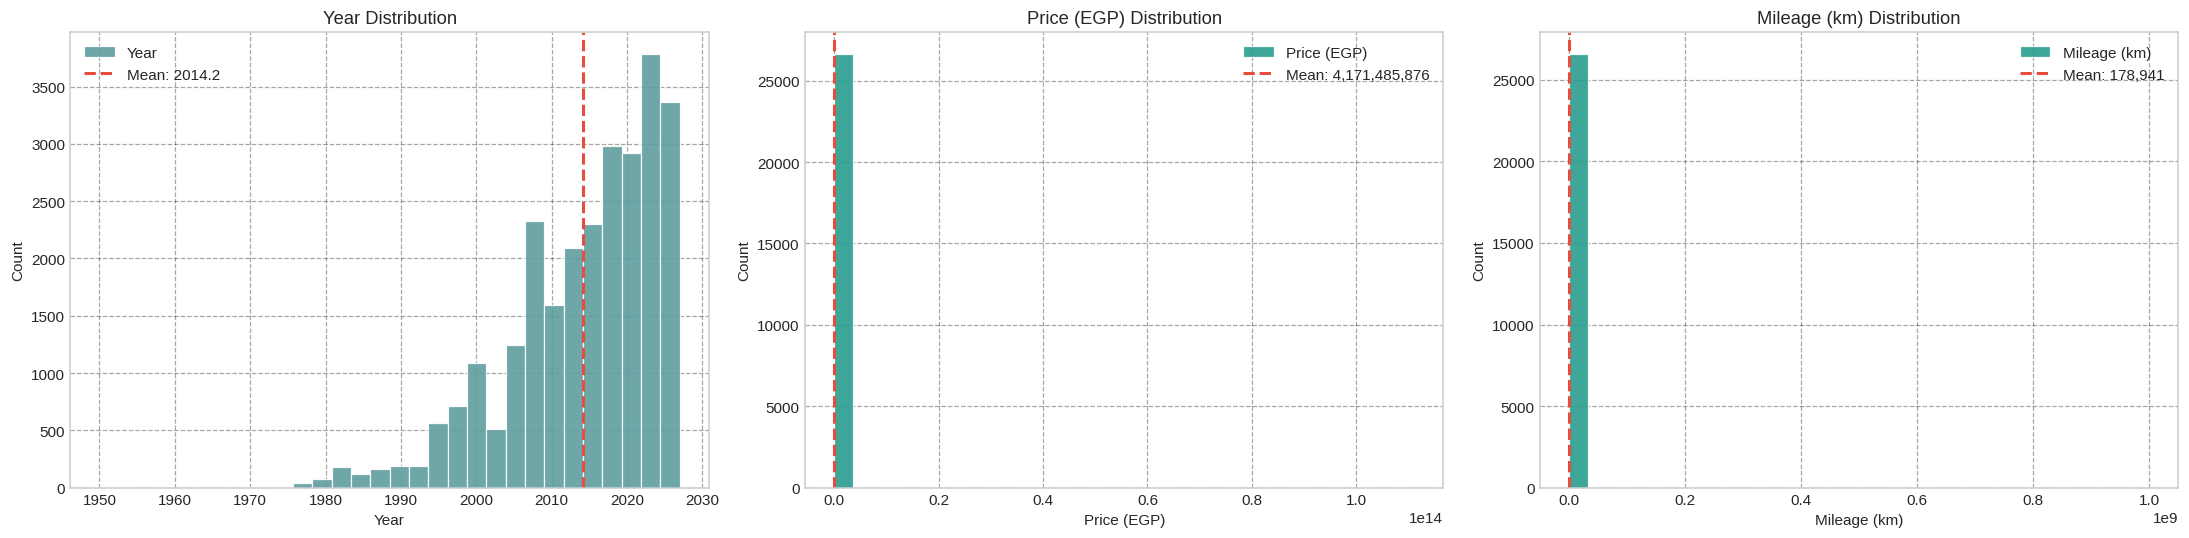

In [156]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

year_series = data["year"].dropna()
price_series = data["price_egp"].dropna()
mileage_series = data["mileage_km"].dropna()

year_mean = year_series.mean()
price_mean = price_series.mean()
mileage_mean = mileage_series.mean()

year_series.hist(
    ax=axes[0],
    bins=30,
    alpha=PLOT_ALPHA,
    color=PLOT_PRIMARY_COLOR,
    edgecolor=PLOT_EDGE_COLOR,
    linewidth=PLOT_HIST_LINEWIDTH,
    label="Year",
)
axes[0].axvline(
    year_mean,
    color=PLOT_ACCENT_COLOR,
    linestyle="--",
    linewidth=PLOT_LINE_WIDTH,
    label=f"Mean: {year_mean:.1f}",
)
axes[0].set_title("Year Distribution")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Count")
axes[0].legend()

price_series.hist(
    ax=axes[1],
    bins=30,
    alpha=PLOT_ALPHA,
    color="#2A9D8F",
    edgecolor=PLOT_EDGE_COLOR,
    linewidth=PLOT_HIST_LINEWIDTH,
    label="Price (EGP)",
)
axes[1].axvline(
    price_mean,
    color=PLOT_ACCENT_COLOR,
    linestyle="--",
    linewidth=PLOT_LINE_WIDTH,
    label=f"Mean: {price_mean:,.0f}",
)
axes[1].set_title("Price (EGP) Distribution")
axes[1].set_xlabel("Price (EGP)")
axes[1].set_ylabel("Count")
axes[1].legend()

mileage_series.hist(
    ax=axes[2],
    bins=30,
    alpha=PLOT_ALPHA,
    color="#2A9D8F",
    edgecolor=PLOT_EDGE_COLOR,
    linewidth=PLOT_HIST_LINEWIDTH,
    label="Mileage (km)",
)
axes[2].axvline(
    mileage_mean,
    color=PLOT_ACCENT_COLOR,
    linestyle="--",
    linewidth=PLOT_LINE_WIDTH,
    label=f"Mean: {mileage_mean:,.0f}",
)
axes[2].set_title("Mileage (km) Distribution")
axes[2].set_xlabel("Mileage (km)")
axes[2].set_ylabel("Count")
axes[2].legend()

plt.tight_layout()
plt.show()

Price and mileage columns are very skewed with un real outliers!!

---

### Inspecting the year outliers

In [157]:
print(f"Number of rows for cars with years > 2026 or < 1975: {data[(data.year > 2026) | (data.year < 1975)].shape[0]}")
data[(data.year > 2026)| (data.year < 1975)].head()

Number of rows for cars with years > 2026 or < 1975: 12


,id,title,make,model,year,mileage_km,transmission,fuel,price_egp,location,scraped_at
13168,13345,Volkswagen Transporter 2027,Volkswagen,Transporter,2027.0,280000.0,Manual,diesel,650000,"Hurghada, Red Sea",2026-02-20 00:43:31.731743
13593,13773,Volkswagen Passat 2027,Volkswagen,Passat,2027.0,239.0,Automatic,petrol,450000,"Heliopolis, Cairo",2026-02-20 00:46:08.475911
14619,14805,Fiat 128 1973,Fiat,128,1973.0,1.0,Manual,petrol,55000,"Menouf, Monufia",2026-02-20 00:52:04.864431
15241,15432,Volkswagen Transporter 1972,Volkswagen,Transporter,1972.0,2222222.0,Manual,cng,120000,Giza,2026-02-20 00:55:33.845278
16812,17014,Mercedes 200 1970,Mercedes,200,1970.0,10000.0,Manual,diesel,250000,"Helwan, Cairo",2026-02-20 01:05:54.011598


In [158]:
print(f"Number of rows for cars with years > 2026 : {data[(data.year > 2026)].shape[0]}")
data[(data.year > 2026)].head()

Number of rows for cars with years > 2026 : 2


,id,title,make,model,year,mileage_km,transmission,fuel,price_egp,location,scraped_at
13168,13345,Volkswagen Transporter 2027,Volkswagen,Transporter,2027.0,280000.0,Manual,diesel,650000,"Hurghada, Red Sea",2026-02-20 00:43:31.731743
13593,13773,Volkswagen Passat 2027,Volkswagen,Passat,2027.0,239.0,Automatic,petrol,450000,"Heliopolis, Cairo",2026-02-20 00:46:08.475911


In [159]:
print(f"Number of rows for cars with years < 1980: {data[(data.year < 1980)].shape[0]}")
print(f"Number of rows for cars with years < 1970: {data[(data.year < 1970)].shape[0]}")
data[(data.year < 1970)]

Number of rows for cars with years < 1980: 71
Number of rows for cars with years < 1970: 1


,id,title,make,model,year,mileage_km,transmission,fuel,price_egp,location,scraped_at
17336,17539,Fiat 127 1950,Fiat,127,1950.0,300000.0,Manual,petrol,35000,Cairo,2026-02-20 01:10:51.120853


---

### Inspect mileage outliers

In [160]:
print(f"Number of rows for cars with years < 2024 and mileage 0: {data[(data['year'] < 2024) & (data['mileage_km'] == 0)].shape[0]}")
print(f"Number of rows for cars with years < 2023 and mileage 0: {data[(data['year'] < 2023) & (data['mileage_km'] == 0)].shape[0]}")
print(f"Number of rows for cars with years < 2015 and mileage 0: {data[(data['year'] < 2015) & (data['mileage_km'] == 0)].shape[0]}")
print(f"Number of rows for cars with years < 2000 and mileage 0: {data[(data['year'] < 2000) & (data['mileage_km'] == 0)].shape[0]}")

Number of rows for cars with years < 2024 and mileage 0: 709
Number of rows for cars with years < 2023 and mileage 0: 642
Number of rows for cars with years < 2015 and mileage 0: 433
Number of rows for cars with years < 2000 and mileage 0: 175


In [161]:
def show_zero_mileage_recent_comparisons(df, n_compare=3, max_year=2023):
    zero_rows = df[(df["mileage_km"] < 5000) & (df["year"] < max_year)].copy()
    if zero_rows.empty:
        return zero_rows

    comparisons = []

    for idx, row in zero_rows.iterrows():
        zero_sample = row.to_frame().T
        zero_sample.insert(0, "row_type", "zero_mileage_recent_row")
        zero_sample.insert(1, "source_zero_row_index", idx)

        base_mask = (
            (df["make"] == row["make"]) &
            (df["model"] == row["model"]) &
            (df["year"] == row["year"]) &
            (df["transmission"] == row["transmission"]) &
            (df["mileage_km"].notna()) &
            (df["mileage_km"] > 5000)
        )

        # # keep only rows with price within ±5% of the zero-mileage row price
        # if pd.notna(row["price_egp"]) and row["price_egp"] > 0:
        #     low = row["price_egp"] * 0.95
        #     high = row["price_egp"] * 1.05
        #     base_mask &= df["price_egp"].between(low, high, inclusive="both")

        same_mmy_nonzero = df[base_mask].head(n_compare).copy()

        if same_mmy_nonzero.empty:
            comparisons.append(zero_sample)
            continue

        same_mmy_nonzero.insert(0, "row_type", "same_make_model_year_nonzero_mileage")
        same_mmy_nonzero.insert(1, "source_zero_row_index", idx)

        comparisons.append(pd.concat([zero_sample, same_mmy_nonzero], ignore_index=True))

    return pd.concat(comparisons, ignore_index=True)


zero_mileage_recent_comparison_df = show_zero_mileage_recent_comparisons(data, n_compare=3, max_year=2023)

print("Rows with mileage < 5000 and year < 2023:", ((data["mileage_km"] < 5000) & (data["year"] < 2023)).sum())
print(
    "Of those, rows that have at least one same make+model+year+transmission with mileage > 5000 and ±5% price:",
    zero_mileage_recent_comparison_df.loc[
        zero_mileage_recent_comparison_df["row_type"] == "same_make_model_year_nonzero_mileage",
        "source_zero_row_index"
    ].nunique()
)

zero_mileage_recent_comparison_df[
    ["make", "model", "year", "transmission", "mileage_km", "price_egp"]
].head(100)

Rows with mileage < 5000 and year < 2023: 1588
Of those, rows that have at least one same make+model+year+transmission with mileage > 5000 and ±5% price: 1369


,make,model,year,transmission,mileage_km,price_egp
0,Fiat,Shahin,1997.0,Manual,150.0,100000
1,Fiat,Shahin,1997.0,Manual,180000.0,90000
2,Fiat,Shahin,1997.0,Manual,66000.0,115000
3,Fiat,Shahin,1997.0,Manual,280000.0,110000
4,Renault,Logan,2017.0,Automatic,190.0,450000
5,Renault,Logan,2017.0,Automatic,300000.0,400000
6,Renault,Logan,2017.0,Automatic,203000.0,325000
7,Renault,Logan,2017.0,Automatic,100000.0,440000
8,Mazda,323,2008.0,Automatic,270.0,320000
9,Mazda,323,2008.0,Automatic,230000.0,410000


I will impute the mileage by the simmilar cars in price, and maybe drop the other 690 rows I have no option! 


but after thinking and review it, this approach may lead to data leakage so I may just drop them!!

In [162]:
data['mileage_km'].quantile([0.95, 0.96, 0.98, 0.99, 0.995, 0.999, 1]).to_frame()

,mileage_km
0.950,320000.0
0.960,350000.0
0.980,410000.0
0.990,500000.0
0.995,999000.0
0.999,1000000.0
1.000,999999999.0


so I must cut any data point of milage > 500k km

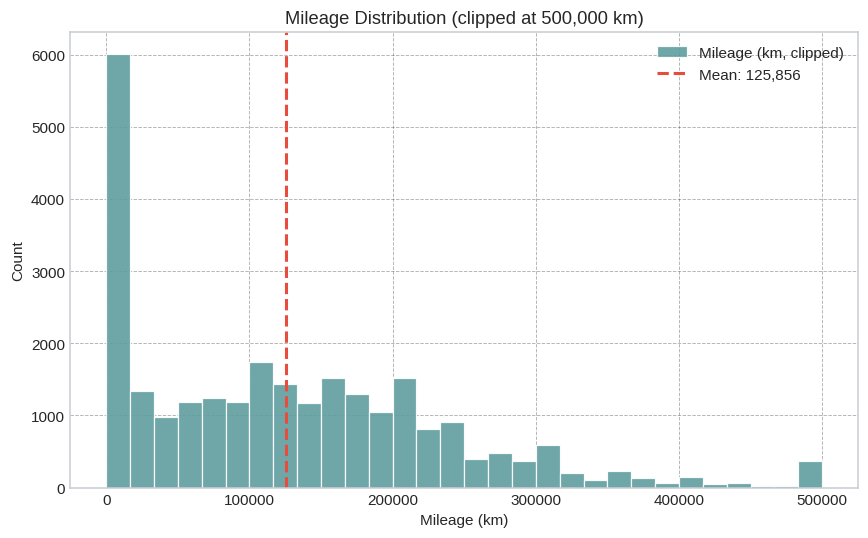

In [163]:
mileage_series = data["mileage_km"].dropna().clip(upper=500_000)
mileage_mean = mileage_series.mean()

fig, ax = plt.subplots(figsize=(8, 5))
mileage_series.hist(
    ax=ax,
    bins=30,
    alpha=PLOT_ALPHA,
    color=PLOT_PRIMARY_COLOR,
    edgecolor=PLOT_EDGE_COLOR,
    linewidth=PLOT_HIST_LINEWIDTH,
    label="Mileage (km, clipped)",
)
ax.axvline(
    mileage_mean,
    color=PLOT_ACCENT_COLOR,
    linestyle="--",
    linewidth=PLOT_LINE_WIDTH,
    label=f"Mean: {mileage_mean:,.0f}",
)

ax.set_title("Mileage Distribution (clipped at 500,000 km)")
ax.set_xlabel("Mileage (km)")
ax.set_ylabel("Count")
ax.legend()
ax.grid(True, which="both", linewidth=0.6, alpha=0.3)

plt.tight_layout()
plt.show()


Mileage is very sensitve predictor so I can't just impute or do anything may introduce fake pattern so I think dropping it is the saffest thing to do if there is no other option

---

### Price outliers

In [164]:
data.price_egp.quantile([0.5, 0.75, 0.9, 0.95, 0.96, 0.98, 0.99, 0.995, 0.998, 0.999, 0.9995, 1]).to_frame()

,price_egp
0.5000,6.100000e+05
0.7500,1.250000e+06
0.9000,2.677500e+06
0.9500,3.950000e+06
0.9600,4.550000e+06
0.9800,6.250000e+06
0.9900,8.000000e+06
0.9950,1.100000e+07
0.9980,1.548450e+07
0.9990,1.867250e+07


In [165]:
quantiles = [0.5, 0.75, 0.9, 0.95, 0.96, 0.98, 0.99, 0.995, 0.998, 0.999, 0.9995, 1]
quantile_values = data.price_egp.quantile(quantiles)
quantile_counts = {}
previous_quantile_value = 0
for q, value in quantile_values.items():
    count_in_range = data[(data.price_egp > previous_quantile_value) & (data.price_egp <= value)].shape[0]
    quantile_counts[q] = count_in_range
    previous_quantile_value = value
for q, count in quantile_counts.items():
    print(f"Quantile {q}: {count} rows")



Quantile 0.5: 13176 rows
Quantile 0.75: 6823 rows
Quantile 0.9: 3825 rows
Quantile 0.95: 1352 rows
Quantile 0.96: 258 rows
Quantile 0.98: 526 rows
Quantile 0.99: 270 rows
Quantile 0.995: 128 rows
Quantile 0.998: 78 rows
Quantile 0.999: 27 rows
Quantile 0.9995: 13 rows
Quantile 1.0: 14 rows


I will drop unitl the 0.998 quanitle anything larger thatn 18M

#### checking the lower bound now

In [166]:
data[data.price_egp < 20000].shape[0]

245

In [167]:
data[data.price_egp < 20000][['make', 'model', 'year', 'mileage_km', 'price_egp']].head(30)

,make,model,year,mileage_km,price_egp
6110,Porsche,Cayenne S,2020.0,125000.0,3750
8259,GMC,Hummer EV,2015.0,10000.0,1000
9486,Fiat,126,1992.0,555.0,15000
11568,Volkswagen,Passat,2011.0,150.0,750
12217,Renault,Rainbow,1999.0,119998.0,10
12287,Changan,Alsvin,2022.0,41000.0,540
12292,Fiat,Shahin,1996.0,65170.0,115
12322,Lada,Granta,2023.0,30000.0,1
12349,Mitsubishi,Lancer EX Shark,2016.0,0.0,600
13402,Toyota,Rush,2020.0,231000.0,8


In [168]:
def show_low_price_on_call_comparisons(df, n_compare=3, low_price_threshold=10000):
    low_rows = df[df["price_egp"].notna() & (df["price_egp"] < low_price_threshold)].copy()
    if low_rows.empty:
        return low_rows

    comparisons = []

    for idx, row in low_rows.iterrows():
        low_sample = row.to_frame().T
        low_sample.insert(0, "row_type", "low_price_row")
        low_sample.insert(1, "source_low_price_row_index", idx)
        low_sample.insert(2, "match_level", "target_row")

        strict_mask = (
            (df["make"] == row["make"]) &
            (df["model"] == row["model"]) &
            (df["year"] == row["year"]) &
            (df["transmission"] == row["transmission"]) &
            (df["price_egp"].notna()) &
            (df["price_egp"] >= low_price_threshold)
        )
        similar = df[strict_mask].copy()
        match_level = "same_make_model_year_transmission"


        if similar.empty:
            comparisons.append(low_sample)
            continue

        similar = similar.sort_values("price_egp").head(n_compare).copy()
        similar.insert(0, "row_type", "similar_non_low_price_row")
        similar.insert(1, "source_low_price_row_index", idx)
        similar.insert(2, "match_level", match_level)

        comparisons.append(pd.concat([low_sample, similar], ignore_index=True))

    return pd.concat(comparisons, ignore_index=True)


price_on_call_comparison_df = show_low_price_on_call_comparisons(
    data, n_compare=3, low_price_threshold=10_000
)

low_price_rows_count = (data["price_egp"].notna() & (data["price_egp"] < 10_000)).sum()
matched_low_price_rows_count = price_on_call_comparison_df.loc[
    price_on_call_comparison_df["row_type"] == "similar_non_low_price_row",
    "source_low_price_row_index"
].nunique()

print("Rows with price < 10,000:", low_price_rows_count)
print("Rows with at least one similar non-low-price match:", matched_low_price_rows_count)

cols_to_show = [
    "make", "model", "year", "transmission", "fuel", "mileage_km", "price_egp", "location"
]
cols_to_show = [c for c in cols_to_show if c in price_on_call_comparison_df.columns]

price_on_call_comparison_df[cols_to_show].head(30)

Rows with price < 10,000: 239
Rows with at least one similar non-low-price match: 212


,make,model,year,transmission,fuel,mileage_km,price_egp,location
0,Porsche,Cayenne S,2020.0,Automatic,petrol,125000.0,3750,"Sheikh Zayed, Giza•"
1,Porsche,Cayenne S,2020.0,Automatic,petrol,115000.0,3950000,"Gladios Garden Compound, 6th of October•"
2,Porsche,Cayenne S,2020.0,Automatic,petrol,65000.0,6600000,"Tagamo3 - New Cairo, Cairo"
3,GMC,Hummer EV,2015.0,Manual,petrol,10000.0,1000,•
4,Volkswagen,Passat,2011.0,Automatic,hybrid,150.0,750,Cairo
5,Volkswagen,Passat,2011.0,Automatic,petrol,175000.0,550000,"Nasr city, Cairo"
6,Volkswagen,Passat,2011.0,Automatic,petrol,300000.0,560000,"Sheraton, Cairo"
7,Volkswagen,Passat,2011.0,Automatic,petrol,250000.0,620000,"Nasr city, Cairo"
8,Renault,Rainbow,1999.0,Manual,petrol,119998.0,10,"6 October, Giza"
9,Renault,Rainbow,1999.0,Manual,petrol,120000.0,175000,"kawn mall, 6th of October•"


Cause the same cars have different mileage I can't impute here by mean or median for similar occurances! This is the Target columns it's impossible!!!!<br>
I have no thing to do except dropping those rows

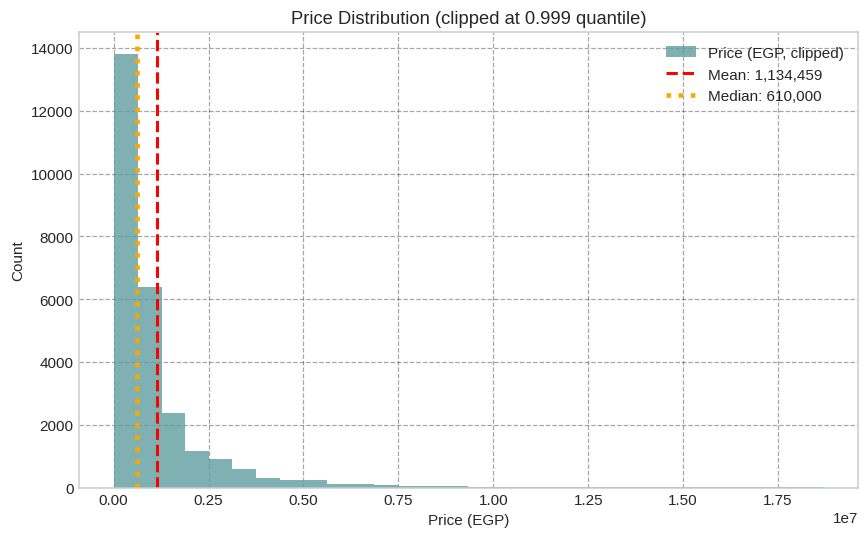

In [169]:
# Clip price to the 0.999 quantile to reduce the effect of extreme outliers on the mean

price_series = data["price_egp"].dropna().clip(upper=data["price_egp"].quantile(0.999), lower=20000)
price_mean = price_series.mean()
price_median = price_series.median()

fig, ax = plt.subplots(figsize=(8, 5))
price_series.hist(ax=ax, bins=30, alpha=0.8, label="Price (EGP, clipped)")
ax.axvline(price_mean, color="red", linestyle="--", linewidth=2, label=f"Mean: {price_mean:,.0f}")
ax.axvline(price_median, color="orange", linestyle=":", linewidth=3, label=f"Median: {price_median:,.0f}")

ax.set_title("Price Distribution (clipped at 0.999 quantile)")
ax.set_xlabel("Price (EGP)")
ax.set_ylabel("Count")
ax.legend()

plt.tight_layout()
plt.show()


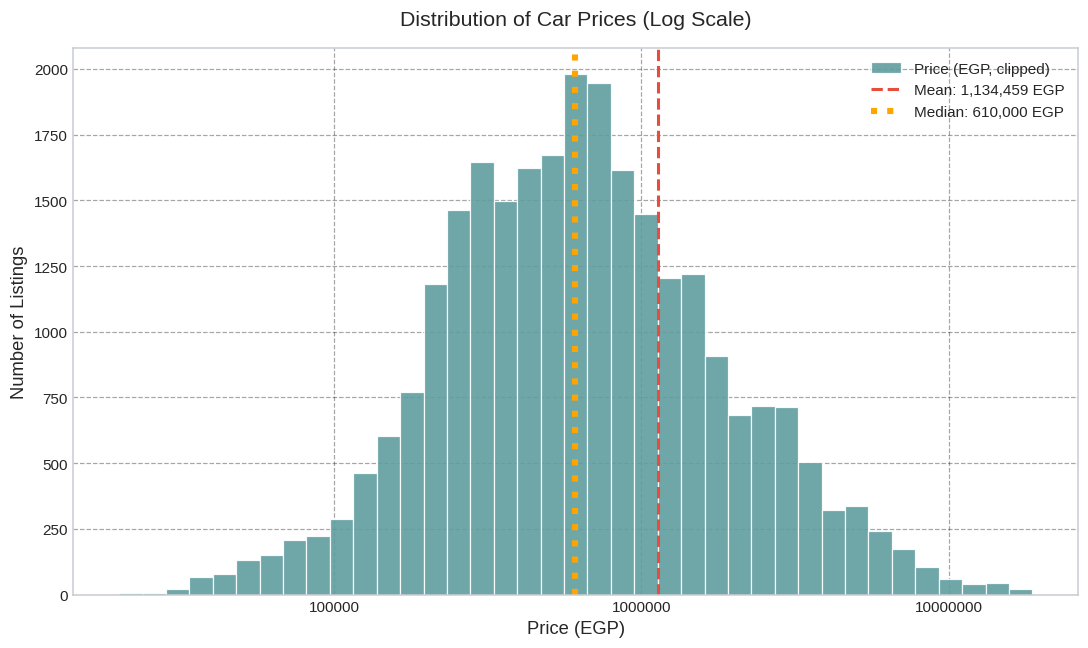

In [170]:

upper_limit = data["price_egp"].quantile(0.999) 
lower_limit = 20000 # To filter out "Price on Call" placeholders

price_series = data["price_egp"].dropna().clip(upper=upper_limit, lower=lower_limit)
price_mean = price_series.mean()
price_median = price_series.median()

fig, ax = plt.subplots(figsize=(10, 6))

bins = np.logspace(np.log10(lower_limit), np.log10(upper_limit), 40)

ax.hist(
    price_series, 
    bins=bins, 
    color=PLOT_PRIMARY_COLOR, 
    edgecolor=PLOT_EDGE_COLOR, 
    linewidth=PLOT_HIST_LINEWIDTH, 
    alpha=PLOT_ALPHA, 
    label="Price (EGP, clipped)"
)

ax.axvline(
    price_mean, 
    color=PLOT_ACCENT_COLOR, 
    linestyle="--", 
    linewidth=PLOT_LINE_WIDTH, 
    label=f"Mean: {price_mean:,.0f} EGP"
)

ax.axvline(
    price_median,
    color='orange', 
    linestyle=":", 
    linewidth=4, 
    label=f"Median: {price_median:,.0f} EGP"
)

ax.set_xscale("log")
ax.set_title("Distribution of Car Prices (Log Scale)", fontsize=14, pad=15)
ax.set_xlabel("Price (EGP)", fontsize=12)
ax.set_ylabel("Number of Listings", fontsize=12)
ax.xaxis.set_major_formatter(ScalarFormatter())
ax.ticklabel_format(style='plain', axis='x')

ax.legend()
plt.tight_layout()
plt.show()

---

---

## I will move this section to data cleainng notebook later

In [171]:
data.head()

,id,title,make,model,year,mileage_km,transmission,fuel,price_egp,location,scraped_at
0,1,Deepal S 07 2025,Deepal,S 07,2025.0,5000.0,Automatic,hybrid,1650000,"Sheikh Zayed, Giza•",2026-02-20 04:45:52
1,2,Chery Tiggo 2026,Chery,Tiggo,2026.0,NaN,Manual,petrol,915000,NaN,2026-02-20 04:50:40
2,3,Byd F3 2024,BYD,F3,2024.0,4410.0,Manual,petrol,630000,"Ramses + Ramses Extension, Cairo•",2026-02-20 04:41:57
3,4,Byd F3 2025,BYD,F3,2025.0,33033.0,Manual,petrol,610000,"Nasr City, Cairo•",2026-02-20 04:54:05
4,5,Subaru Impreza 2009,Subaru,Impreza,2009.0,98000.0,Manual,petrol,410000,"Maadi, Cairo•",2026-02-20 04:41:57


In [172]:
data['location'].nunique()

1096

In [173]:
data['location'].value_counts().to_frame().head(10)

,count
location,
"Tagamo3 - New Cairo, Cairo",1882
Cairo,1838
"Nasr city, Cairo",1439
"6 October, Giza",900
"New Cairo, Cairo•",808
Alexandria,755
"Nasr City, Cairo•",635
5th Settlement,629
"5th Settlement, New Cairo•",626


In [174]:
# data['government'] = (
#     data['location']
#     .str.split(",").str[-1]
#     .str.strip()
#     .replace(r'[^a-zA-Z0-9\s]', '', regex=True)
#     .replace('', "Unknown")
# )

In [175]:
# data.government.nunique()

In [176]:
# data.government.value_counts().to_frame().head(20)


In [177]:
def normalize_locations(df: pd.DataFrame, col: str = "location") -> pd.DataFrame:
    """
    Normalize raw Egyptian car marketplace location strings into
    clean, model-ready location categories.

    Strategy:
    - Hierarchical np.select: specific neighborhoods checked before broad cities
    - Sparse governorates (< 300 rows each) consolidated into 'Delta (Other)'
    - Anything unmatched → 'Other/Unknown' (includes raw '•' placeholders)
    - Raw location column is NOT dropped here — caller decides what to keep

    Final categories (17):
        New Cairo, October & Zayed, Nasr City, Heliopolis, Maadi,
        Alexandria, Cairo, Giza, Qalyubia,
        Sharqia, Dakahlia, Gharbia, Canal Zone,
        Delta (Other) [= Monufia + Kafr el-Sheikh + Beheira + Damietta],
        Upper Egypt, Coastal & Resorts, Other/Unknown

    Parameters
    ----------
    df  : DataFrame containing the raw location column
    col : Name of the raw location column (default: 'location')

    Returns
    -------
    location column fixed and normalized
    """

    # ── 1. Pre-clean ────────────────────────────────────────────────────────
    # Convert NaN to "nan" string so str methods work uniformly.
    # Strip all non-alphanumeric characters (bullet •, comma, dash, etc.)
    clean_s = (
        df[col]
        .astype(str)
        .str.lower()
        .str.replace(r"[^a-z0-9\s]", " ", regex=True)
        .str.strip()
    )

    # ── 2. Conditions (ORDER MATTERS — specific before general) ─────────────
    conditions = [

        # ── TIER 1: New Cairo cluster (East Cairo) ──────────────────────────
        # 'badr' intentionally excluded — Badr City is 80 km east, not New Cairo
        clean_s.str.contains(
            r"tagamo|new cairo|settlement|rehab|madinaty|mostakbal|shorouk|katameya",
            na=False,
        ),

        # ── TIER 2: October & Zayed cluster (West Cairo) ────────────────────
        clean_s.str.contains(r"october|zayed", na=False),

        # ── TIER 3: Major Cairo districts ───────────────────────────────────
        # Checked before broad 'cairo' to avoid misclassification
        clean_s.str.contains(r"nasr city", na=False),

        clean_s.str.contains(
            r"heliopolis|masr el gedida|masr al jadidah|sheraton",
            na=False,
        ),

        clean_s.str.contains(r"maadi|basatin|tora", na=False),

        # ── TIER 4: Alexandria + western suburbs ────────────────────────────
        # 'agami' AND 'agamy' — both spellings appear in the data
        # 'amreya'/'amereyah' — Alexandria western district
        # 'borg al arab' — Alexandria new city
        clean_s.str.contains(
            r"alexandria|agami|agamy|smoha|smouha|sidi gaber|gaber"
            r"|beshr|asafra|miami|borg al arab|amreya|amereyah",
            na=False,
        ),

        # ── TIER 5: Cairo (broad catchall) ──────────────────────────────────
        # Covers: Helwan, Mokattam, Shubra, Ain Shams, Matareya, Marg,
        #         Obour City (listed as Cairo), Badr City (listed as Cairo),
        #         Rod al-Farag, Salam City, downtown districts
        # Note: 'shubra' is here AND Shubra al-Khaimah is in Qalyubia below.
        #       np.select takes first match — Cairo checked first, but
        #       'shubra al khaymah'/'shubra al khaimah' won't match 'shubra'
        #       alone only if you match exact. To be safe, Qalyubia regex
        #       uses full 'shubra al khaymah' pattern.
        clean_s.str.contains(
            r"cairo|mokattam|helwan|downtown|shubra|nozha|nozah"
            r"|badr city|obour|salam city|ain shams|matareya"
            r"|marg|rod al farag|hadayek al kobba|abidin|gesr al suez",
            na=False,
        ),

        # ── TIER 6: Giza ────────────────────────────────────────────────────
        # 'mariotya' and 'mariotaya' — Maryoteyya district in Giza
        # 'hadayek al ahram' — Pyramids Gardens area in Giza
        # 'ramses' — Ramses area borders Giza
        clean_s.str.contains(
            r"giza|haram|faisal|dokki|imbaba|mohandessin|pyramids"
            r"|mariotaya|maryotaya|mariotya|hadayek al ahram|hadayek october"
            r"|ramses",
            na=False,
        ),

        # ── TIER 7: Qalyubia ────────────────────────────────────────────────
        # Full 'shubra al khaymah' pattern catches Shubra al-Khaimah correctly
        # 'obour city' also listed as Qalyubia in some entries
        clean_s.str.contains(
            r"qalyubia|banha|shubra al khaymah|shubra al khaimah|shubrakhit",
            na=False,
        ),

        # ── TIER 8: Sharqia ─────────────────────────────────────────────────
        # '10th of ramadan' is in Sharqia governorate — some listings
        # incorrectly say 'Cairo'; Sharqia condition checked before Cairo
        # so they are classified correctly
        clean_s.str.contains(
            r"sharqia|zagazig|10th of ramadan|bilbeis",
            na=False,
        ),

        # ── TIER 9: Dakahlia ────────────────────────────────────────────────
        # 'mansura' and 'mansoura' — common spelling variants
        clean_s.str.contains(r"dakahlia|mansoura|mansura", na=False),

        # ── TIER 10: Gharbia ────────────────────────────────────────────────
        clean_s.str.contains(r"gharbia|tanta|mahalla", na=False),

        # ── TIER 11: Monufia → will be consolidated into Delta (Other) ──────
        clean_s.str.contains(r"monufia|menofia|menufeya|shebin|sadat", na=False),

        # ── TIER 12: Kafr el-Sheikh → Delta (Other) ─────────────────────────
        # 'kafr el cheik' — common misspelling found in the data
        clean_s.str.contains(
            r"kafr el sheikh|kafr al sheikh|kafr el cheik|kafr elsheikh",
            na=False,
        ),

        # ── TIER 13: Beheira → Delta (Other) ────────────────────────────────
        # 'el behiera' / 'behiera' — misspelling found in the data
        clean_s.str.contains(
            r"beheira|behiera|damanhour|kafr el dawwar|kafr al dawwar",
            na=False,
        ),

        # ── TIER 14: Damietta → Delta (Other) ───────────────────────────────
        clean_s.str.contains(r"damietta", na=False),

        # ── TIER 15: Canal Zone ──────────────────────────────────────────────
        # Ismailia, Port Said, Suez, Ain Sokhna
        clean_s.str.contains(r"ismailia|port said|suez|ain sokhna", na=False),

        # ── TIER 16: Upper Egypt ─────────────────────────────────────────────
        # 'el wadi el gedid' / 'new valley' — remote western governorate
        clean_s.str.contains(
            r"fayoum|faiyum|beni suef|ben suef|minya|asyut|sohag"
            r"|qena|luxor|aswan|kom ombo|wadi el gedid|wadi gedid|new valley",
            na=False,
        ),

        # ── TIER 17: Coastal & Resorts ───────────────────────────────────────
        # Red Sea, North Coast, Sinai
        clean_s.str.contains(
            r"red sea|hurghada|gouna|matruh|mersa matruh|marsa matrouh"
            r"|north coast|sahel|sinai|sharm",
            na=False,
        ),
    ]

    choices = [
        "New Cairo",        # Tier 1
        "October & Zayed",  # Tier 2
        "Nasr City",        # Tier 3a
        "Heliopolis",       # Tier 3b
        "Maadi",            # Tier 3c
        "Alexandria",       # Tier 4
        "Cairo",            # Tier 5
        "Giza",             # Tier 6
        "Qalyubia",         # Tier 7
        "Sharqia",          # Tier 8
        "Dakahlia",         # Tier 9
        "Gharbia",          # Tier 10
        "Monufia",          # Tier 11 → consolidated below
        "Kafr el-Sheikh",   # Tier 12 → consolidated below
        "Beheira",          # Tier 13 → consolidated below
        "Damietta",         # Tier 14 → consolidated below
        "Canal Zone",       # Tier 15
        "Upper Egypt",      # Tier 16
        "Coastal & Resorts",# Tier 17
    ]

    # ── 3. Apply selection ───────────────────────────────────────────────────
    df["location"] = np.select(conditions, choices, default="Other/Unknown")

    # ── 4. Handle actual nulls and placeholder-only strings ─────────────────
    # After .astype(str), original NaN → "nan"; bullet-only rows → "  " etc.
    df.loc[df[col].isna(), "location"] = "Other/Unknown"
    df.loc[clean_s.isin(["", "nan", "none"]), "location"] = "Other/Unknown"

    # ── 5. Consolidate sparse governorates into Delta (Other) ───────────────
    # Each of these has < 350 rows — too sparse for reliable independent signal.
    # Combined they form a meaningful 'Delta region (other)' group (~940 rows).
    sparse_governorates = {"Monufia", "Kafr el-Sheikh", "Beheira", "Damietta"}
    df["location"] = df["location"].replace(
        {gov: "Delta (Other)" for gov in sparse_governorates}
    )

    return df["location"]


# ── Final category reference ─────────────────────────────────────────────────
LOCATION_CATEGORIES = [
    # Greater Cairo cluster (~65% of listings)
    "New Cairo",         # 19.7% — Tagamo3, 5th Settlement, Rehab, Shorouk
    "Cairo",             # 18.5% — Helwan, Mokattam, Shubra, Ain Shams, etc.
    "October & Zayed",   # 10.2% — 6 October, Sheikh Zayed
    "Nasr City",         #  9.0% — Cairo district, distinct market
    "Giza",              #  8.2% — Haram, Faisal, Dokki, Mohandessin
    "Heliopolis",        #  5.3% — Masr el Gedida, Sheraton
    "Maadi",             #  2.6% — Maadi, Basatin, Tora

    # Other major cities
    "Alexandria",        #  7.4% — All Alexandria + western suburbs

    # Delta governorates (each 2-2.5%)
    "Sharqia",           #  2.3%
    "Gharbia",           #  2.3%
    "Dakahlia",          #  2.0%
    "Qalyubia",          #  1.5%
    "Delta (Other)",     #  3.6% — Monufia + Kafr el-Sheikh + Beheira + Damietta

    # Other regions
    "Canal Zone",        #  1.8% — Ismailia, Port Said, Suez
    "Upper Egypt",       #  3.0% — Minya, Asyut, Sohag, Luxor, Aswan, etc.
    "Coastal & Resorts", #  1.0% — Hurghada, North Coast, Sinai, Matrouh

    # Fallback
    "Other/Unknown",     #  1.6% — Raw '•' placeholders + unmatched strings
]


data['location'] = normalize_locations(data, col="location")

In [178]:
data['location'].value_counts().to_frame()

,count
location,
New Cairo,5170
Cairo,4847
October & Zayed,2685
Nasr City,2347
Giza,2163
Alexandria,1947
Heliopolis,1394
Delta (Other),942
Other/Unknown,872
